In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=128, shuffle=True)

100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:07<00:00, 3.37MB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 181kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:03<00:00, 1.21MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 11.9MB/s]


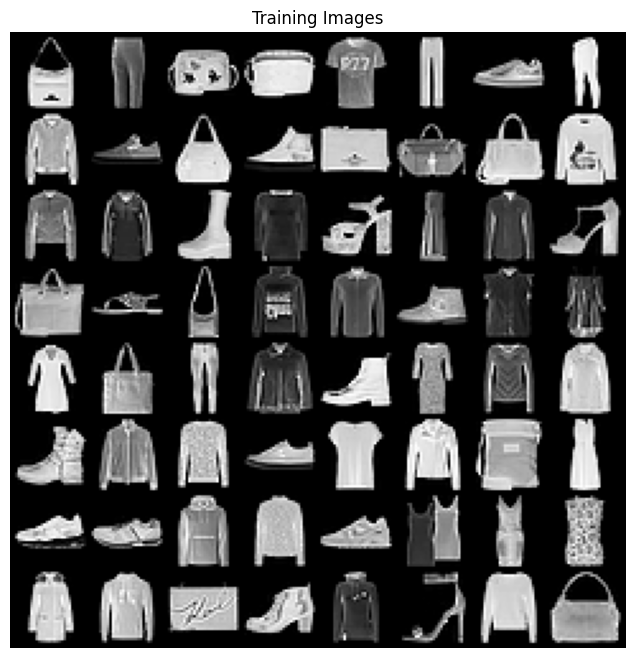

In [4]:
images, labels = next(iter(loader))

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")

grid = torchvision.utils.make_grid(images[:64], normalize=True)

plt.imshow(np.transpose(grid,(1,2,0)))
plt.show()

In [5]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,784),
            nn.Tanh()
        )

    def forward(self,z):

        img = self.model(z)

        img = img.view(-1,1,28,28)

        return img

In [6]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,img):

        img = img.view(img.size(0),-1)

        validity = self.model(img)

        return validity

In [7]:
G = Generator().to(device)
D = Discriminator().to(device)

In [8]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = optim.Adam(D.parameters(), lr=0.0002)

In [9]:
epochs = 20

for epoch in range(epochs):

    for imgs,_ in loader:

        real_imgs = imgs.to(device)

        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)

        # Train Discriminator
        optimizer_D.zero_grad()

        real_loss = criterion(D(real_imgs), real_labels)

        z = torch.randn(batch_size,100).to(device)
        fake_imgs = G(z)

        fake_loss = criterion(D(fake_imgs.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        d_loss.backward()

        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        g_loss = criterion(D(fake_imgs), real_labels)

        g_loss.backward()

        optimizer_G.step()

    print("Epoch:", epoch+1,
          "D Loss:", d_loss.item(),
          "G Loss:", g_loss.item())

Epoch: 1 D Loss: 0.11159944534301758 G Loss: 4.398064136505127
Epoch: 2 D Loss: 0.362003892660141 G Loss: 5.755103588104248
Epoch: 3 D Loss: 0.2577146291732788 G Loss: 4.10817289352417
Epoch: 4 D Loss: 0.3507828712463379 G Loss: 4.610506534576416
Epoch: 5 D Loss: 0.7795913219451904 G Loss: 2.9863779544830322
Epoch: 6 D Loss: 0.8805986046791077 G Loss: 3.460482597351074
Epoch: 7 D Loss: 0.4027310311794281 G Loss: 3.6650431156158447
Epoch: 8 D Loss: 0.33926716446876526 G Loss: 2.9934661388397217
Epoch: 9 D Loss: 0.11474832147359848 G Loss: 3.6023142337799072
Epoch: 10 D Loss: 0.6810756921768188 G Loss: 2.980257034301758
Epoch: 11 D Loss: 0.3829082250595093 G Loss: 2.834559679031372
Epoch: 12 D Loss: 0.9041986465454102 G Loss: 2.6692733764648438
Epoch: 13 D Loss: 0.8040469288825989 G Loss: 3.434807777404785
Epoch: 14 D Loss: 0.43928661942481995 G Loss: 3.063598871231079
Epoch: 15 D Loss: 0.6924625635147095 G Loss: 2.4511590003967285
Epoch: 16 D Loss: 0.5204604864120483 G Loss: 2.734361410

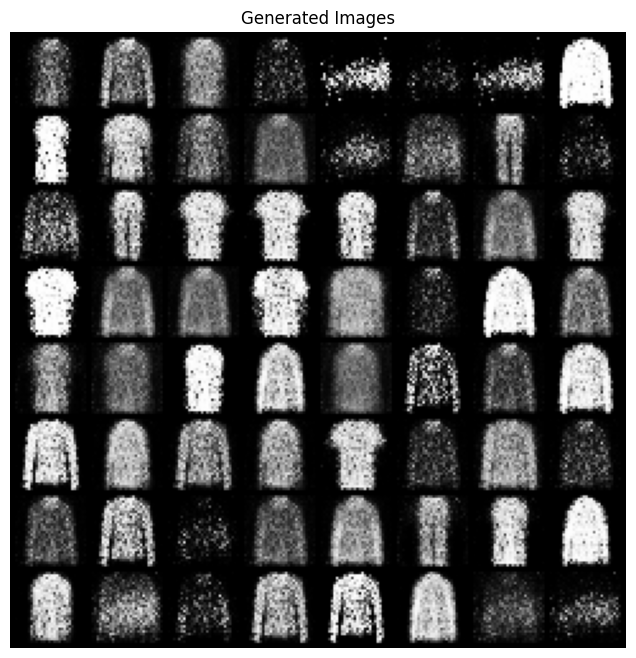

In [10]:

z = torch.randn(64,100).to(device)

generated_images = G(z).detach().cpu()

grid = vutils.make_grid(generated_images,8,normalize=True)

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Generated Images")

plt.imshow(np.transpose(grid,(1,2,0)))

plt.show()

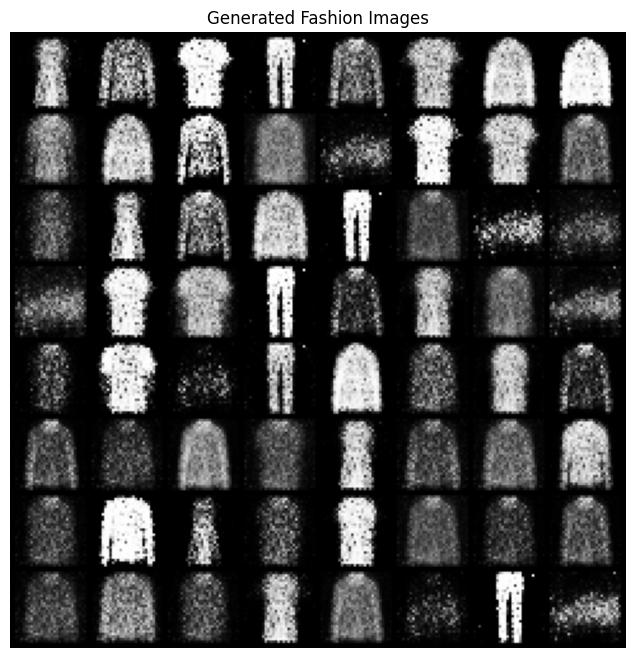

In [11]:

vutils.save_image(generated_images,"generated_samples.png",normalize=True)
     

z = torch.randn(64,100).to(device)

generated = G(z).detach().cpu()
     

grid = torchvision.utils.make_grid(generated,8,normalize=True)

plt.figure(figsize=(8,8))
plt.axis("off")

plt.title("Generated Fashion Images")

plt.imshow(np.transpose(grid,(1,2,0)))

plt.show()

In [14]:
torchvision.utils.save_image(generated,"gan_generated_images.png",normalize=True)
     

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(100,256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),

            nn.Linear(256,512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),

            nn.Linear(512,1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),

            nn.Linear(1024,784),
            nn.Tanh()
        )

    def forward(self,z):

        img = self.model(z)

        img = img.view(-1,1,28,28)

        return img
     

In [15]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(784,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,img):

        img = img.view(img.size(0),-1)

        validity = self.model(img)

        return validity

In [16]:

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))
     

epochs = 50
     

if epoch % 10 == 0:

    z = torch.randn(64,100).to(device)

    samples = G(z).detach().cpu()

    grid = torchvision.utils.make_grid(samples,8,normalize=True)

    plt.figure(figsize=(6,6))
    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.axis("off")
    plt.title("Epoch "+str(epoch))
    plt.show()

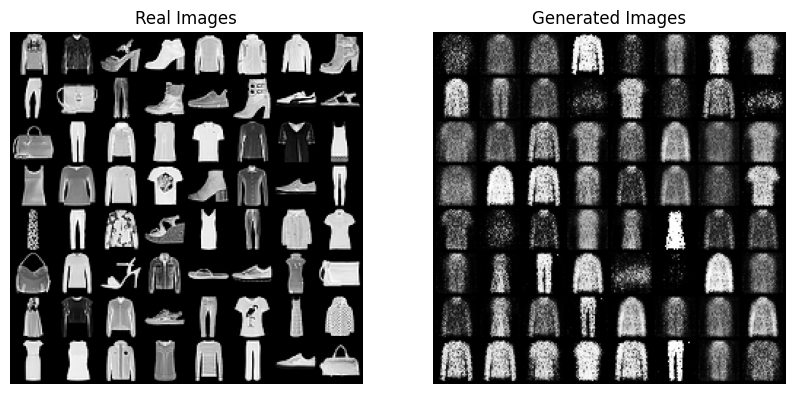

In [17]:
real_images,_ = next(iter(loader))

real_grid = torchvision.utils.make_grid(real_images[:64],8,normalize=True)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Real Images")
plt.axis("off")
plt.imshow(np.transpose(real_grid,(1,2,0)))

plt.subplot(1,2,2)
plt.title("Generated Images")
plt.axis("off")
plt.imshow(np.transpose(grid,(1,2,0)))

plt.show()